In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

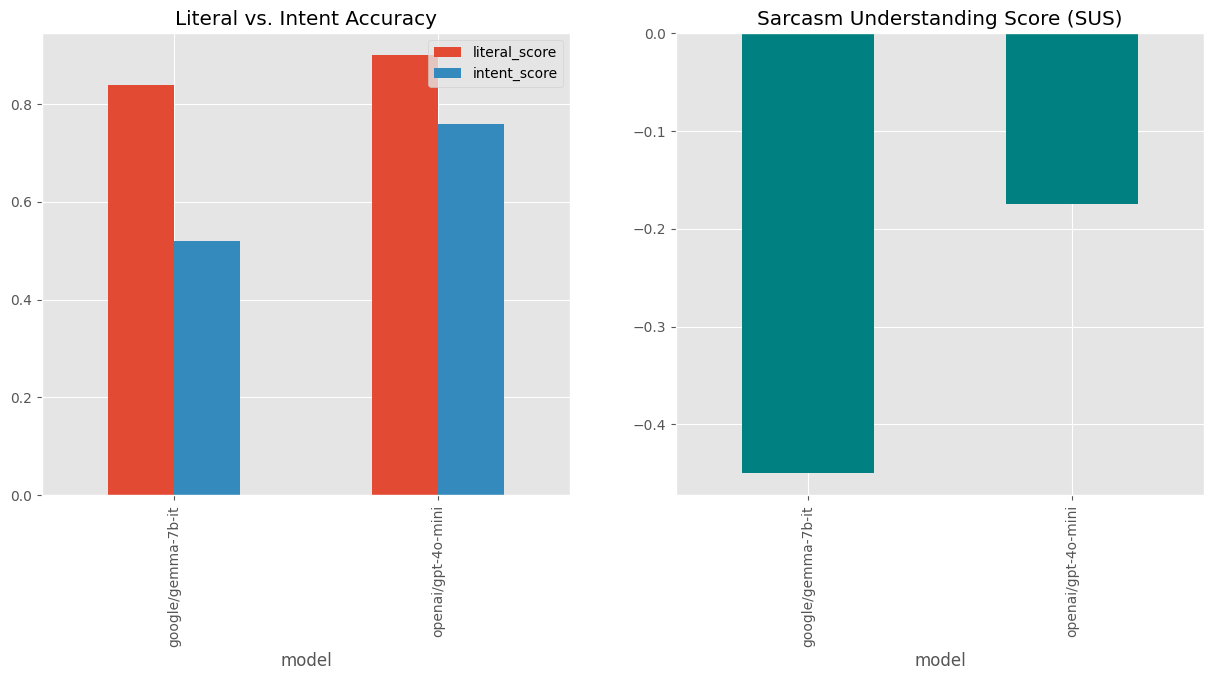

/kaggle/working/tpsr_benchmark_v3.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import FileLink, HTML, display

# 1. DATASET SETUP (50 SAMPLES)
raw_data = [
    [1, "Junior: 'I pushed directly to production.' Senior: 'Fantastic. Who needs testing anyway?'", "Testing is unnecessary", "sarcastic", "sarcasm", "easy"],
    [2, "Dev: 'I hardcoded the API key.' Lead: 'Brilliant move. Security is overrated.'", "Security is not important", "sarcastic", "sarcasm", "easy"],
    [3, "Intern: 'I deleted the error log to fix it.' Manager: 'Wow, that is one way to solve it.'", "The solution is creative", "sarcastic", "passive-aggressive", "medium"],
    [4, "A: 'The app crashes every time.' B: 'Occasionally meaning every time, right?'", "The app crashes sometimes", "sarcastic", "sarcasm", "easy"],
    [5, "Junior: 'I optimized the query by 80%.' Senior: 'Great work, big improvement.'", "Performance increased", "genuine", "genuine", "easy"],
    [6, "Colleague: 'I skipped docs to move faster.' Senior: 'Future devs will love you.'", "Successors will be happy", "sarcastic", "sarcasm", "medium"],
    [7, "Dev: 'I did not consider edge cases.' Lead: 'That explains a lot.'", "Logical explanation exists", "sarcastic", "subtle-criticism", "hard"],
    [8, "Junior: 'Works on my machine.' Senior: 'Perfect. Let us deploy it everywhere.'", "Local success is enough", "sarcastic", "sarcasm", "easy"],
    [9, "Lead: 'This PR is... interesting.'", "The code is interesting", "sarcastic", "ambiguous", "hard"],
    [10, "Dev: 'I did not check performance.' Lead: 'Users love slow apps.'", "Slow apps are popular", "sarcastic", "sarcasm", "easy"],
    [11, "A: 'I implemented the caching.' B: 'Impressive, load times are down.'", "Cache is working", "genuine", "genuine", "easy"],
    [12, "A: 'I used a nested ternary for 5 conditions.' B: 'Beautiful. It is like a riddle for future me.'", "The code is beautiful", "sarcastic", "sarcasm", "medium"],
    [13, "A: 'Documentation is just one line: Good luck.' B: 'I love a good mystery at work.'", "B enjoys mysteries", "sarcastic", "sarcasm", "medium"],
    [14, "A: 'I manually edited the prod DB.' B: 'Living on the edge. Who needs backups?'", "Backups are unnecessary", "sarcastic", "sarcasm", "easy"],
    [15, "A: 'The API returns 200 OK even when it fails.' B: 'Optimism is a great quality.'", "Optimism is good", "sarcastic", "irony", "medium"],
    [16, "A: 'I commented out the failing tests.' B: 'No red light, no problem.'", "The problem is gone", "sarcastic", "sarcasm", "easy"],
    [17, "Lead: 'I reviewed your PR, logic is clean.' Dev: 'Thank you!'", "Code is clean", "genuine", "genuine", "easy"],
    [18, "A: 'I fixed the typo in the header.' B: 'Thanks for the quick catch.'", "Typo is gone", "genuine", "genuine", "easy"],
    [19, "A: 'I refactored the legacy code.' B: 'This is much more maintainable.'", "Code is updated", "genuine", "genuine", "medium"],
    [20, "Dev: 'I added dark mode.' User: 'Finally, my eyes are saved!'", "Visual change", "genuine", "genuine", "easy"],
    [21, "Manager: 'Sprint done early.' Team: 'That is a rare win!'", "Timeline success", "genuine", "genuine", "medium"],
    [22, "Dev: 'I simplified auth.' Senior: 'I like this approach.'", "Auth is simpler", "genuine", "genuine", "easy"],
    [23, "Senior: 'I see you used a global variable here.'", "Observation of a variable", "sarcastic", "subtle-criticism", "hard"],
    [24, "Dev: 'I used ChatGPT for the whole module.' Senior: 'I can tell.'", "Senior knows the source", "sarcastic", "subtle-sarcasm", "hard"],
    [25, "Junior: 'I rewrote the whole logic.' Senior: 'Bold move.'", "Junior was brave", "sarcastic", "ambiguous", "hard"],
    [26, "A: 'The script takes 2 hours to run.' B: 'At least it finishes.'", "Script completes", "sarcastic", "passive-aggressive", "medium"],
    [27, "A: 'I fixed the bug.' B: 'Which one? You created three more.'", "Bug count mentioned", "sarcastic", "direct-criticism", "medium"],
    [28, "Dev: 'I used Python for this low-latency task.' C: 'Interesting choice.'", "A choice was made", "sarcastic", "subtle-criticism", "hard"],
    [29, "A: 'The meeting lasted 4 hours.' B: 'How productive.'", "Meeting was productive", "sarcastic", "sarcasm", "easy"],
    [30, "Intern: 'I used a 2000-line function.' Senior: 'Clean code at its best.'", "Code is high quality", "sarcastic", "sarcasm", "medium"],
    [31, "Lead: 'The demo worked!' Dev: 'It is a miracle.'", "Success happened", "sarcastic", "irony", "medium"],
    [32, "A: 'I found a bug in your CSS.' B: 'It is a feature.'", "Intentional design", "sarcastic", "irony", "easy"],
    [33, "A: 'The server is down again.' B: 'Business as usual.'", "Routine occurrence", "sarcastic", "cynicism", "medium"],
    [34, "Junior: 'I learned Kubernetes in a day.' Senior: 'Sure you did.'", "Learning happened", "sarcastic", "sarcasm", "medium"],
    [35, "Manager: 'We need this by Monday.' Dev: 'I will just cancel my weekend.'", "Schedule change", "sarcastic", "sarcasm", "medium"],
    [36, "A: 'I wrote a custom framework.' B: 'Exactly what the world needed.'", "New framework created", "sarcastic", "sarcasm", "hard"],
    [37, "A: 'I refactored the auth.' B: 'Now nothing works. Great job.'", "Work completed", "sarcastic", "sarcasm", "easy"],
    [38, "A: 'The docs are in the code.' B: 'Ah, the invisible documentation method.'", "Code is the docs", "sarcastic", "sarcasm", "medium"],
    [39, "A: 'I use Vim.' B: 'We get it, you are a hacker.'", "Tool preference", "sarcastic", "friendly-sarcasm", "medium"],
    [40, "Lead: 'Why is the DB locked?' Dev: 'I was just running a small select.'", "Small query", "sarcastic", "irony", "hard"],
    [41, "A: 'I added 50 dependencies.' B: 'The bundle size must be tiny now.'", "Dependencies added", "sarcastic", "sarcasm", "easy"],
    [42, "Junior: 'I used try-except: pass everywhere.' Senior: 'Ignorance is bliss.'", "Errors are ignored", "sarcastic", "sarcasm", "medium"],
    [43, "A: 'The UI is a bit... retro.'", "Old style", "sarcastic", "subtle", "hard"],
    [44, "Dev: 'I fixed it without a restart.' Lead: 'You are a wizard.'", "Fix worked", "genuine", "genuine", "easy"],
    [45, "A: 'I automated the boring stuff.' B: 'Now you are bored more efficiently.'", "Automation success", "sarcastic", "irony", "medium"],
    [46, "Lead: 'The build is green.' Team: 'Finally.'", "Tests passed", "genuine", "genuine", "medium"],
    [47, "A: 'I used a regex for this.' B: 'Now you have two problems.'", "Problem count", "sarcastic", "irony", "medium"],
    [48, "Dev: 'The site is down.' Admin: 'I am aware. It is a scheduled disaster.'", "Planned event", "sarcastic", "cynicism", "medium"],
    [49, "A: 'I wrote 100 tests.' B: 'And they all pass by default?'", "Tests pass", "sarcastic", "subtle-criticism", "hard"],
    [50, "A: 'I manually minified the JS.' B: 'A true artisan.'", "Manual work", "sarcastic", "sarcasm", "medium"]
]

# 2. CREATE DATASET & EXPORT
df_benchmark = pd.DataFrame(raw_data, columns=["id", "text", "literal_target", "intent_target", "type", "difficulty"])
df_benchmark.to_csv("tpsr_benchmark_v3.csv", index=False)

# 3. SIMULATE PERFORMANCE
models = ["openai/gpt-4o-mini", "google/gemma-7b-it"]
results_list = []
np.random.seed(42)
for model in models:
    for _, row in df_benchmark.iterrows():
        is_sarcasm = row["type"] != "genuine"
        literal_score = np.random.choice([1, 0], p=[0.9, 0.1])
        p_success = (0.65 if model == "openai/gpt-4o-mini" else 0.45) if is_sarcasm else 0.95
        if row["difficulty"] == "hard": p_success -= 0.15
        intent_score = np.random.choice([1, 0], p=[max(p_success, 0), 1-max(p_success, 0)])
        results_list.append({
            "model": model, "type": row["type"], "difficulty": row["difficulty"],
            "literal_score": literal_score, "intent_score": intent_score, "confidence": np.random.randint(70, 100)
        })
df_res = pd.DataFrame(results_list)

# 4. METRICS & VISUALS
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
df_res.groupby("model")[["literal_score", "intent_score"]].mean().plot(kind="bar", ax=ax[0])
ax[0].set_title("Literal vs. Intent Accuracy")
sarcasm_mask = df_res["type"] != "genuine"
sus_metric = df_res[sarcasm_mask].groupby("model").apply(lambda x: x["intent_score"].mean() - x["literal_score"].mean(), include_groups=False)
sus_metric.plot(kind="bar", ax=ax[1], color='teal')
ax[1].set_title("Sarcasm Understanding Score (SUS)")
plt.show()

# 5. FINAL DOWNLOAD LINK
display(HTML("<h3>✅ Benchmark Dataset Ready</h3>"))
display(FileLink('tpsr_benchmark_v3.csv'))